In [1]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb


In [3]:
df = pd.read_csv('diabetes dirtydata.csv')

In [4]:
df.head()
df.isnull().sum()
df.duplicated().sum()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            763 non-null    float64
 2   Diastolic_BP       733 non-null    float64
 3   Skin_Fold          541 non-null    float64
 4   Serum_Insulin      394 non-null    float64
 5   BMI                757 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.columns

Index(['Pregnant', 'Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin',
       'BMI', 'Diabetes_Pedigree', 'Age', 'Class'],
      dtype='object')

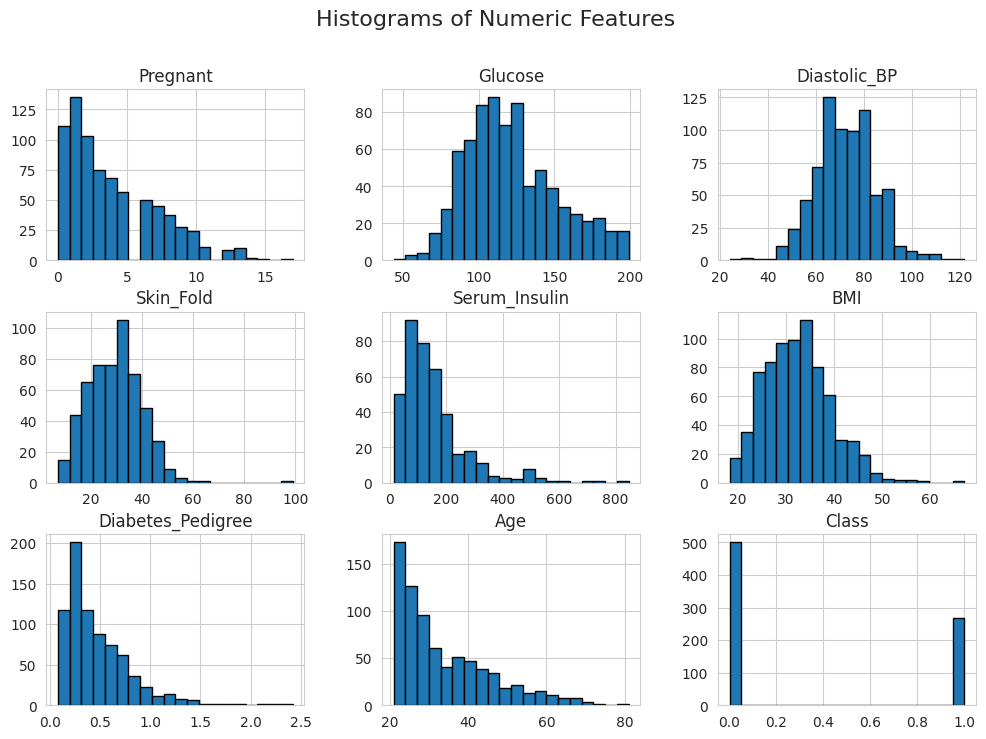

In [9]:
# Set the style for seaborn
sns.set_style("whitegrid")

# 1. Histogram for all numeric columns
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

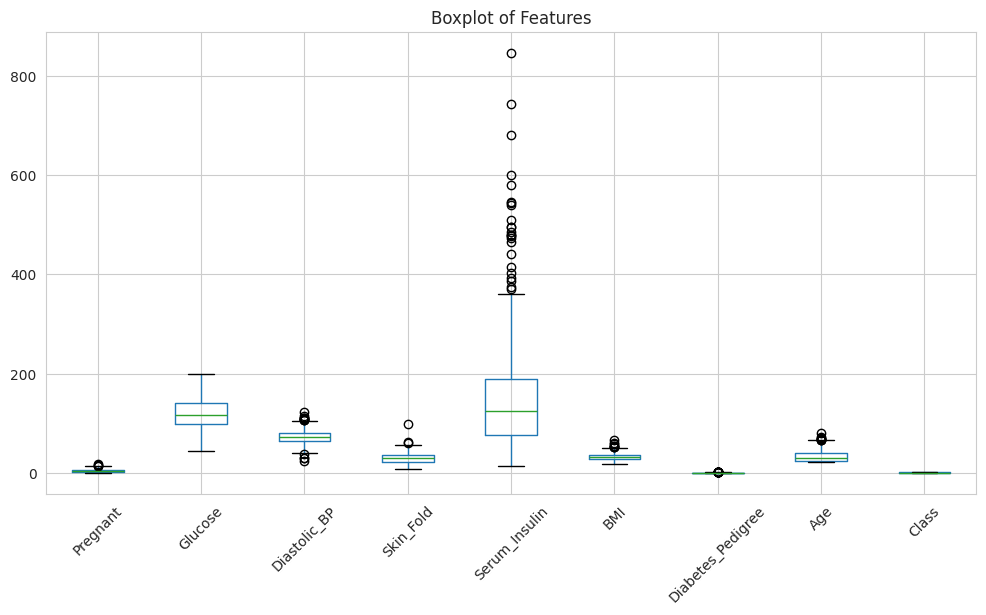

In [10]:
# 2. Boxplot for all numeric columns
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

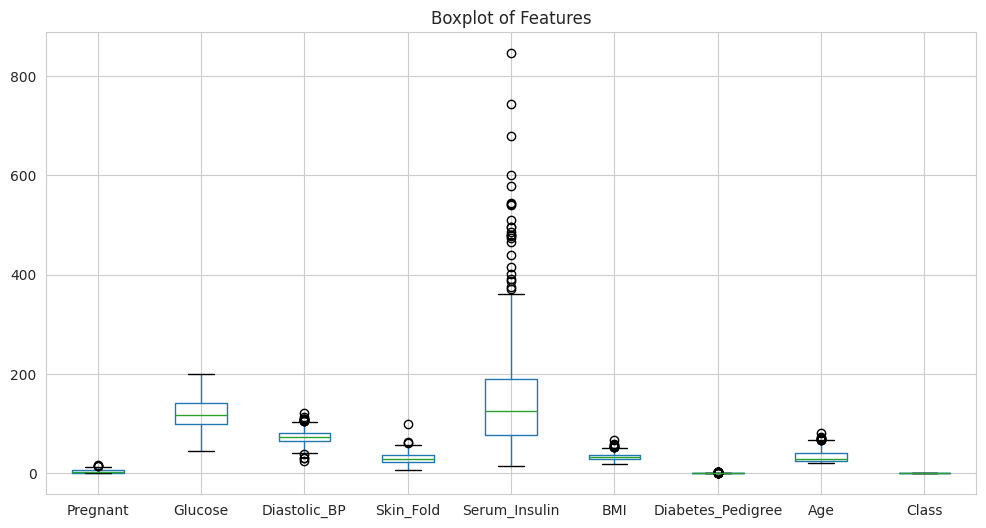

In [11]:
# 2. Boxplot for all numeric columns
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplot of Features")

plt.show()

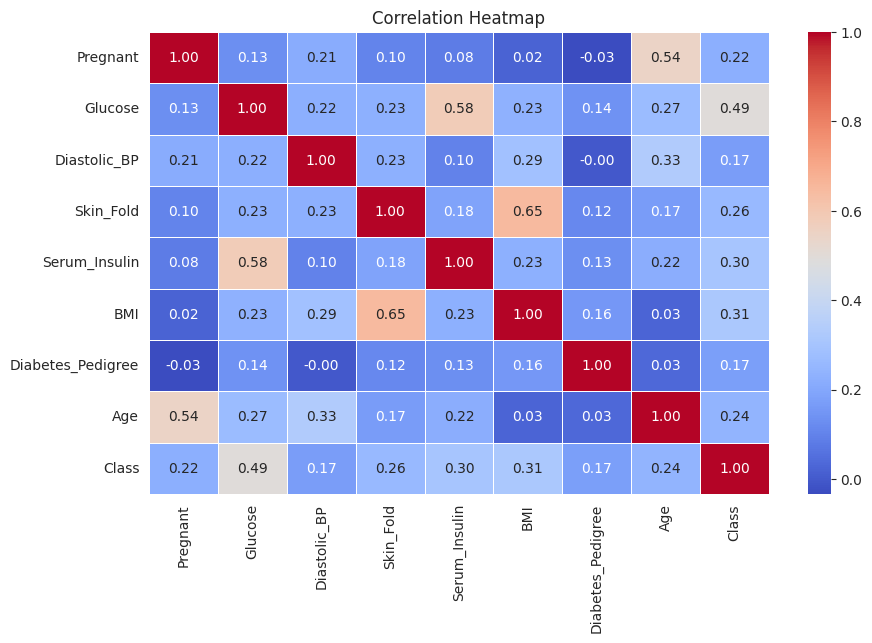

In [12]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipykernel_16174/1162560535.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Class"], palette="coolwarm")


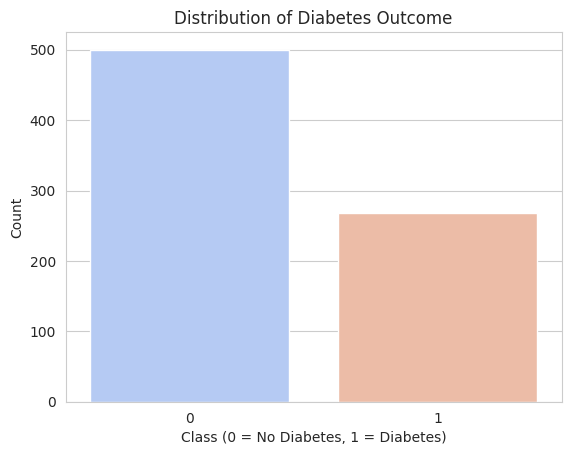

In [14]:
# 5. Countplot for Class distribution
sns.countplot(x=df["Class"], palette="coolwarm")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Class (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

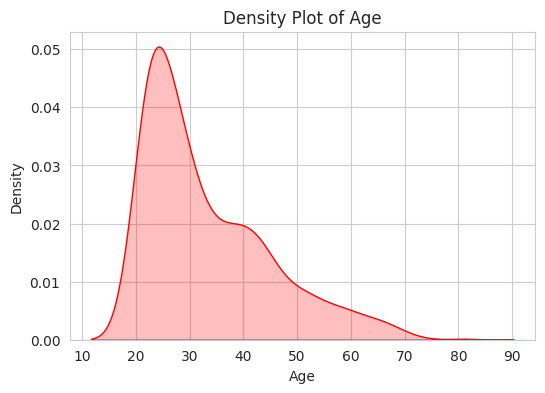

In [22]:
# 6-9. KDE Plots for numerical variables
features = ["Glucose", "Diastolic_BP", "BMI", "Age"]
for feature in features:
    plt.figure(figsize=(6, 4))
sns.kdeplot(df[feature], fill=True, color="red")
plt.title(f"Density Plot of {feature}")
plt.xlabel(feature)
plt.show()

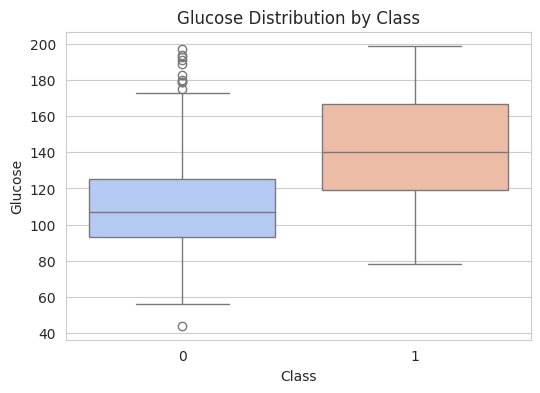

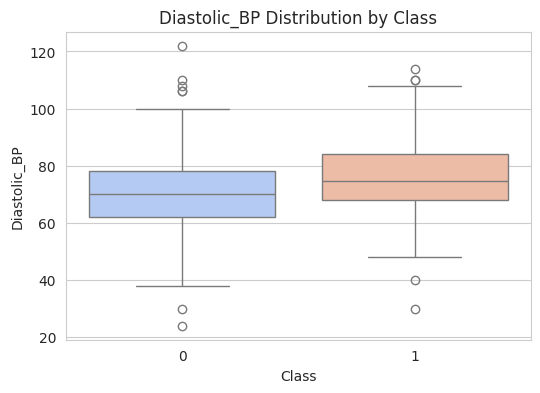

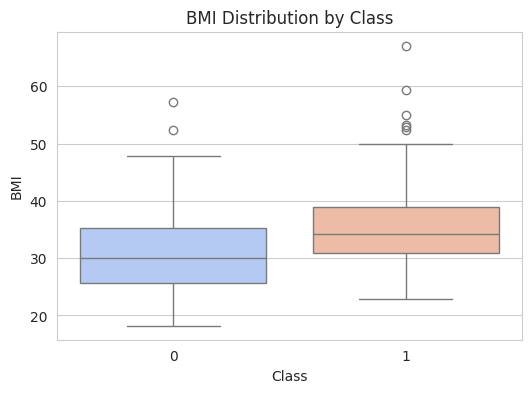

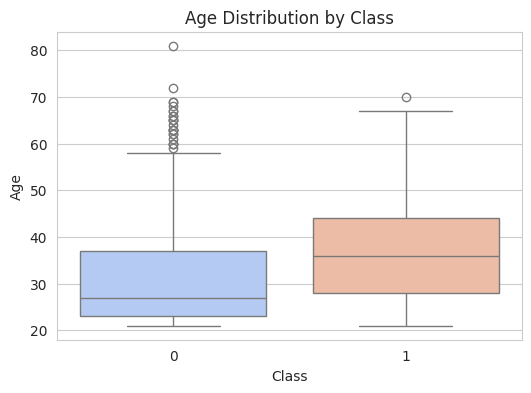

In [23]:
# 10-13. Boxplots for numeric features grouped by Class
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Class", y=feature, data=df, hue="Class", palette="coolwarm", legend=False)
    plt.title(f"{feature} Distribution by Class")
    plt.show()

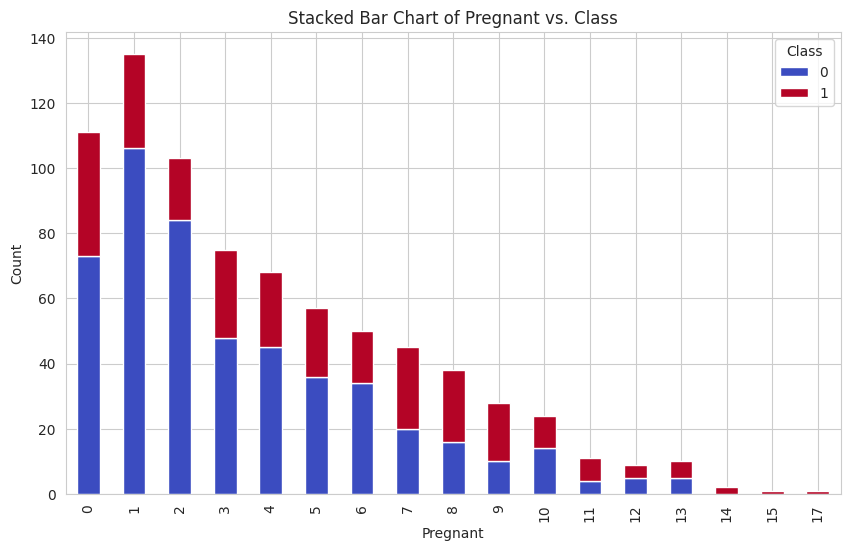

In [25]:
# 24. Stacked bar plot for Class vs. Pregnancies
cross_tab = pd.crosstab(df['Pregnant'], df['Class'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="coolwarm")
plt.title("Stacked Bar Chart of Pregnant vs. Class")
plt.ylabel("Count")
plt.xlabel("Pregnant")
plt.show()

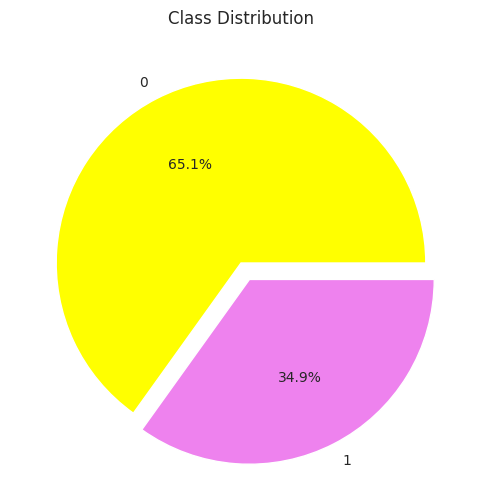

In [42]:
# 25. Pie chart for Class
plt.figure(figsize=(6, 6))
df["Class"].value_counts().plot.pie(autopct='%1.1f%%', colors=["yellow", "violet"], explode=[0, 0.1])
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

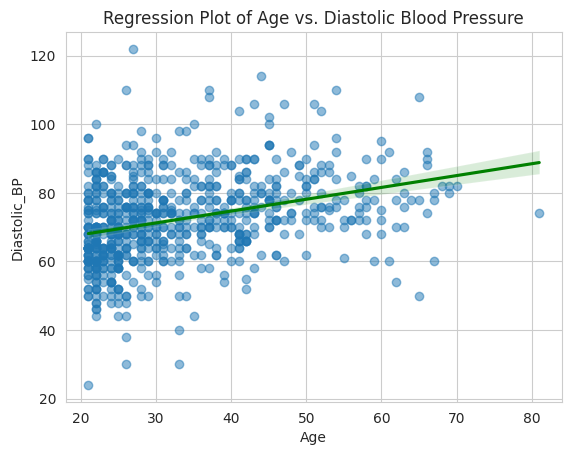

In [41]:
# 29. Regression plot for Diastolic_BP vs. Age
sns.regplot(x="Age", y="Diastolic_BP", data=df, scatter_kws={'alpha':0.5}, line_kws={"color": "green"})
plt.title("Regression Plot of Age vs. Diastolic Blood Pressure")
plt.show()

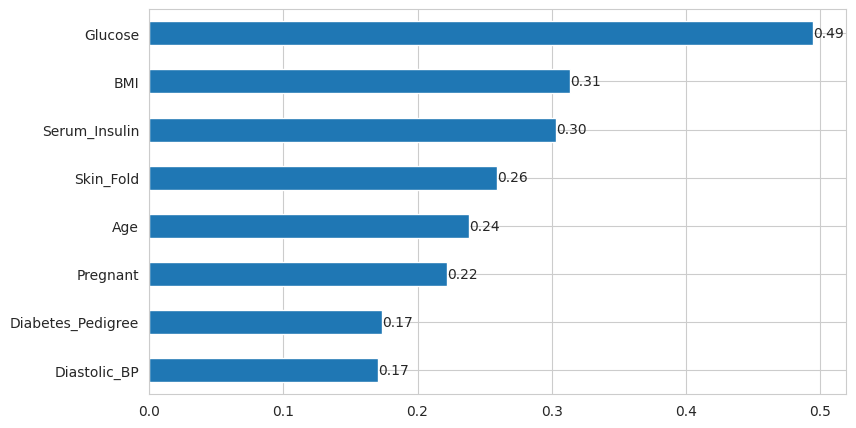

In [29]:
plt.figure(figsize=(9,5))
ax = df.corr()["Class"].drop("Class").sort_values().plot.barh()
ax.bar_label(ax.containers[0], fmt='%.2f');

In [35]:
# Step 5: Define features (X) and target (y)
X = df.drop("Class", axis=1)  # Features
y = df["Class"]  # Target variable

# Step 6: Handle missing values with imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # You can choose 'median' or other strategies
X_imputed = imputer.fit_transform(X)

# Step 7: Normalize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 8: Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# Step 8: Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Support Vector Machine": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),

    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier()
}

In [36]:
# Step 9: Train and evaluate models
model_results = {}

for name, model in models.items():
    print(f"Training {name}...")

     # Step 10: Train the model

    model.fit(X_train, y_train)

    # Step 11: Make predictions
    y_pred = model.predict(X_test)

    # Step 12: Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    model_results[name] = [accuracy, auc]

    # Step 13: Print classification report
    print(f"\n{name} - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Step 14: Convert results to DataFrame
results_df = pd.DataFrame(model_results, index=["Accuracy", "AUC"]).T
results_df = results_df.sort_values(by="Accuracy", ascending=False)

Training Logistic Regression...

Logistic Regression - Accuracy: 0.6948, AUC: 0.8117
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       100
           1       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154

--------------------------------------------------
Training K-Nearest Neighbors...

K-Nearest Neighbors - Accuracy: 0.7403, AUC: 0.8037
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.61      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154

--------------------------------------------------
Training Decision Tree...

Decision Tree - Accuracy: 0.6883, AUC: 0.6322
 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:18:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model Performance Comparison:
                         Accuracy       AUC
Gradient Boosting       0.766234  0.826852
XGBoost                 0.759740  0.797963
AdaBoost                0.746753  0.817963
Random Forest           0.746753  0.808056
LightGBM                0.740260  0.810185
K-Nearest Neighbors     0.740260  0.803704
Support Vector Machine  0.740260  0.791667
Logistic Regression     0.694805  0.811667
Naive Bayes             0.694805  0.769630
Decision Tree           0.688312  0.632222


/tmp/ipykernel_16174/2453995724.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="coolwarm")


Text(0.5, 1.0, 'Model Accuracy Comparison')

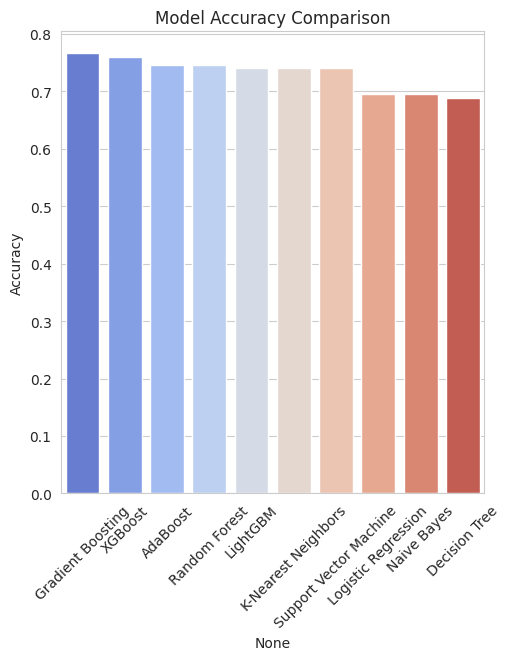

In [37]:
# Step 15: Display model performance comparison
print("\nModel Performance Comparison:\n", results_df)

# Step 16: Plot Accuracy and AUC Scores
plt.figure(figsize=(12, 6))

# Step 17: Bar plot for Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")

/tmp/ipykernel_16174/3039930523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["AUC"], palette="coolwarm")


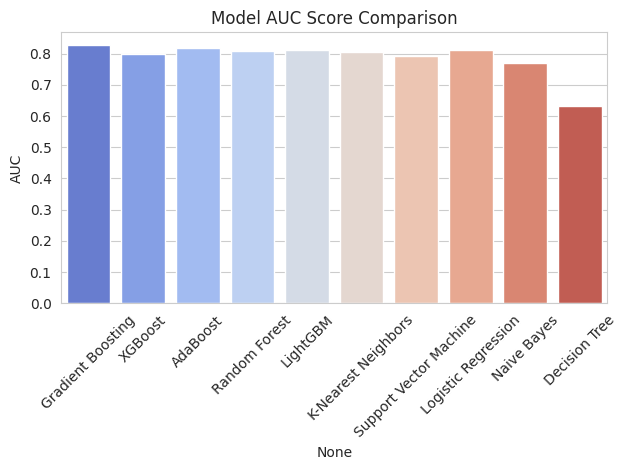

In [38]:
# Step 18: Bar plot for AUC
plt.subplot(1, 1, 1)
sns.barplot(x=results_df.index, y=results_df["AUC"], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model AUC Score Comparison")

plt.tight_layout()
plt.show()

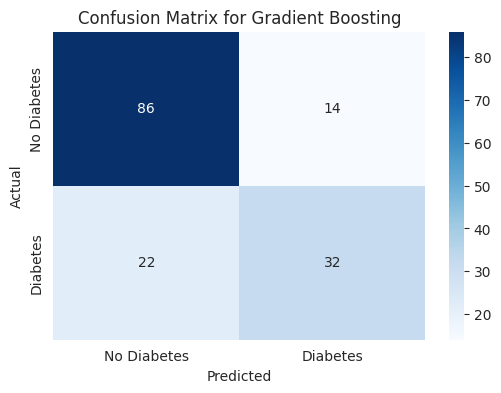

In [39]:
# Step 19: Display Confusion Matrix for Best Model
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()